In [3]:
import pandas as pd

# Define file paths
tiktok_file = '/content/reconstructed_results_tiktok.csv'
youtube_file = '/content/result_youtube (2).csv'

# Read the TikTok dataset
try:
    df_tiktok = pd.read_csv(tiktok_file)
    print(f"Successfully loaded {tiktok_file}")
    print("TikTok DataFrame columns before renaming:", df_tiktok.columns.tolist())
    # Rename 'User_name' to 'Username' in the TikTok dataframe
    if 'User_name' in df_tiktok.columns:
        df_tiktok.rename(columns={'User_name': 'Username'}, inplace=True)
        print("TikTok 'User_name' column renamed to 'Username'.")
    elif 'Username' not in df_tiktok.columns:
        print("Warning: 'User_name' column not found in TikTok data, and 'Username' is also not present.")
    else:
        print("TikTok already has 'Username' column.")

except FileNotFoundError:
    print(f"Error: TikTok file not found at {tiktok_file}")
    df_tiktok = pd.DataFrame()
except Exception as e:
    print(f"Error reading TikTok file: {e}")
    df_tiktok = pd.DataFrame()

# Read the YouTube dataset
try:
    df_youtube = pd.read_csv(youtube_file)
    print(f"Successfully loaded {youtube_file}")
    print("YouTube DataFrame columns:", df_youtube.columns.tolist())
except FileNotFoundError:
    print(f"Error: YouTube file not found at {youtube_file}")
    df_youtube = pd.DataFrame()
except Exception as e:
    print(f"Error reading YouTube file: {e}")
    df_youtube = pd.DataFrame()

# Check if both dataframes were loaded successfully before proceeding
if not df_tiktok.empty and not df_youtube.empty:
    # Identify common columns
    common_columns = list(set(df_tiktok.columns) & set(df_youtube.columns))
    print(f"\nCommon columns between TikTok and YouTube datasets: {common_columns}")

    # Concatenate the dataframes
    # Using join='outer' to keep all columns from both dataframes, filling with NaN where columns don't align
    combined_df = pd.concat([df_tiktok, df_youtube], ignore_index=True, join='outer')

    print("\nCombined DataFrame created.")
    print(f"Total rows in combined DataFrame: {len(combined_df)}")
    print("Combined DataFrame columns:", combined_df.columns.tolist())
    print("\nHead of the combined DataFrame:")
    print(combined_df.head())
else:
    print("\nCannot concatenate: one or both dataframes could not be loaded.")


Successfully loaded /content/reconstructed_results_tiktok.csv
TikTok DataFrame columns before renaming: ['user_name', 'comment', 'comment_likes', 'predicted_sentiment', 'confidence', 'prediction_source']
Successfully loaded /content/result_youtube (2).csv
YouTube DataFrame columns: ['user_name', 'comment', 'predicted_sentiment', 'confidence', 'prediction_source']

Common columns between TikTok and YouTube datasets: ['comment', 'predicted_sentiment', 'confidence', 'user_name', 'prediction_source']

Combined DataFrame created.
Total rows in combined DataFrame: 61949
Combined DataFrame columns: ['user_name', 'comment', 'comment_likes', 'predicted_sentiment', 'confidence', 'prediction_source']

Head of the combined DataFrame:
    user_name                              comment  comment_likes  \
0  manelamara  les commentaires : مافيكمشي حل 😂!!🫨            1.0   
1  manelamara                                  ♥♥♥            0.0   
2  manelamara                                   😊😊           

In [4]:
combined_df.head()

,user_name,comment,comment_likes,predicted_sentiment,confidence,prediction_source
0,manelamara,les commentaires : مافيكمشي حل 😂!!🫨,1.0,Negative,1.0,hf_llm_batch
1,manelamara,♥♥♥,0.0,Neutral,1.0,emoji_lexicon
2,manelamara,😊😊,1.0,Positive,1.0,emoji_lexicon
3,manelamara,🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰🥰,0.0,Positive,1.0,emoji_lexicon
4,manelamara,😂😂😂,0.0,Positive,1.0,emoji_lexicon


In [14]:
import pandas as pd

ml_file = '/content/dataset_ml (2).csv'

try:
    df_ml = pd.read_csv(ml_file)
    print(f"Successfully loaded {ml_file}")
    print("dataset_ml DataFrame columns:", df_ml.columns.tolist())
except FileNotFoundError:
    print(f"Error: ML file not found at {ml_file}")
    df_ml = pd.DataFrame()
except Exception as e:
    print(f"Error reading ML file: {e}")
    df_ml = pd.DataFrame()

# Check if df_ml was loaded successfully
if not df_ml.empty:
    # Merge combined_df with df_ml on 'user_name' as the join key
    # Using how='outer' to include all rows from both dataframes
    final_combined_df = pd.merge(combined_df, df_ml, on='user_name', how='outer')

    print("\nFinal combined DataFrame created.")
    print(f"Total rows in final combined DataFrame: {len(final_combined_df)}")
    print("Final combined DataFrame columns: ", final_combined_df.columns.tolist())
    print("\nHead of the final combined DataFrame:")
    display(final_combined_df.head())
else:
    print("\nCannot merge: the ML dataset could not be loaded.")

Successfully loaded /content/dataset_ml (2).csv
dataset_ml DataFrame columns: ['user_name', 'nom', 'categorie', 'instagram_followers', 'instagram_following', 'instagram_posts', 'tiktok_followers', 'youtube_subscribers', 'youtube_views', 'score_influence', 'niveau', 'audience_totale', 'categorie_encoded', 'ratio_ff', 'nb_plateformes']

Final combined DataFrame created.
Total rows in final combined DataFrame: 62221
Final combined DataFrame columns:  ['user_name', 'comment', 'comment_likes', 'predicted_sentiment', 'confidence', 'prediction_source', 'nom', 'categorie', 'instagram_followers', 'instagram_following', 'instagram_posts', 'tiktok_followers', 'youtube_subscribers', 'youtube_views', 'score_influence', 'niveau', 'audience_totale', 'categorie_encoded', 'ratio_ff', 'nb_plateformes']

Head of the final combined DataFrame:


,user_name,comment,comment_likes,predicted_sentiment,confidence,prediction_source,nom,categorie,instagram_followers,instagram_following,instagram_posts,tiktok_followers,youtube_subscribers,youtube_views,score_influence,niveau,audience_totale,categorie_encoded,ratio_ff,nb_plateformes
0,نورة في المطبخ // Noura à la Cuisine,صباحك حب صديقتي يعطيك ألف صحه قبل ما نتفرج ❤,NaN,Positive,0.975,hf_llm_batch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,نورة في المطبخ // Noura à la Cuisine,ريعطيك الصحة عالتوضيح الكل انا بيدي نبدى خايفة...,NaN,Positive,0.975,hf_llm_batch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,نورة في المطبخ // Noura à la Cuisine,Ya3tik sa7a teslem yedeiyétek Snin Daima ❤❤😂,NaN,Positive,0.9633,hf_llm_batch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,نورة في المطبخ // Noura à la Cuisine,❤❤❤❤❤❤❤,NaN,Positive,0.95,emoji_lexicon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,نورة في المطبخ // Noura à la Cuisine,❤❤❤❤❤❤❤❤❤❤,NaN,Positive,0.95,emoji_lexicon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
final_combined_df.shape

(62221, 20)

In [7]:
final_combined_df["categorie"].unique()

array([nan, 'Actors', 'Food', 'Singer', 'Lifestyle', 'Humor',
       'Makeup Artist', 'Rap', 'Modeling', 'TV Host', 'Fashion',
       'Video Blogger', 'Sport', 'Doctor', 'Photographer', 'Travel'],
      dtype=object)

<Axes: >

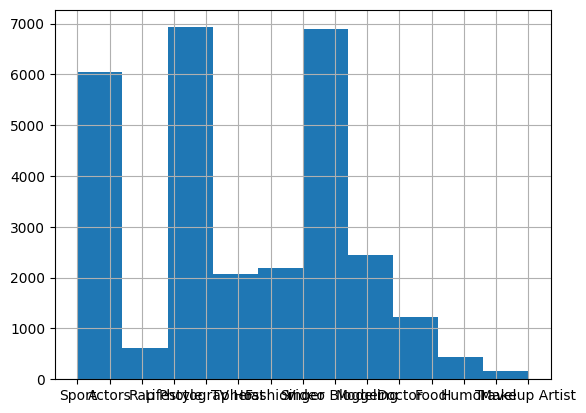

In [16]:
final_combined_df["categorie"].hist()

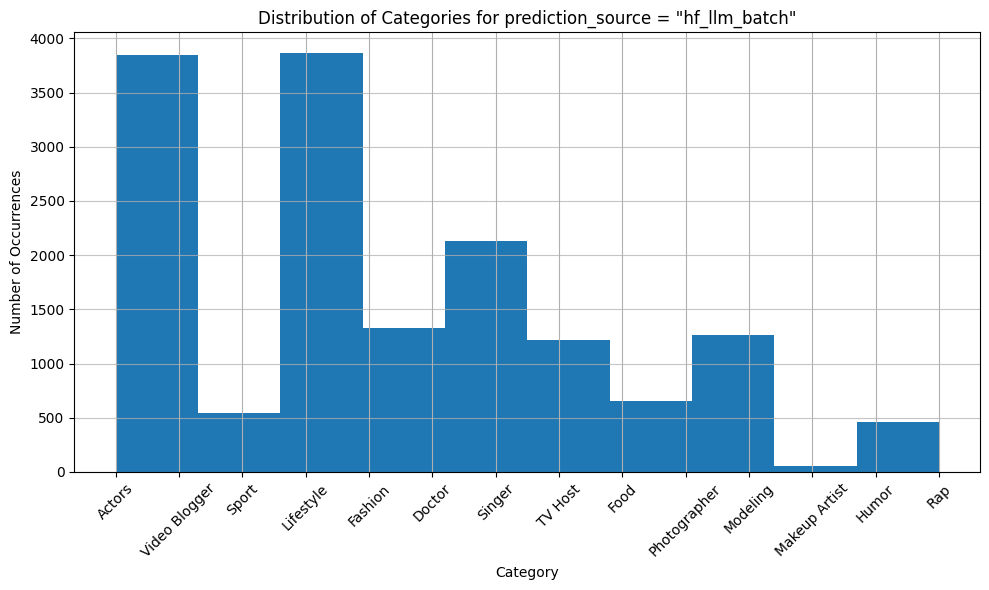

In [17]:
# Filter final_combined_df where 'prediction_source' is 'hf_llm_batch'
filtered_for_plot_df = final_combined_df[final_combined_df['prediction_source'] == 'hf_llm_batch']

# Plot the histogram of 'categorie' for the filtered DataFrame
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
filtered_for_plot_df['categorie'].hist(xrot=45)
plt.title('Distribution of Categories for prediction_source = "hf_llm_batch"')
plt.xlabel('Category')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


In [18]:
# Filter the DataFrame for prediction_source == 'hf_llm_batch'
filtered_df = final_combined_df[final_combined_df['prediction_source'] == 'hf_llm_batch'].copy()

# Drop rows where 'categorie' is NaN, as we need categories for grouping
filtered_df.dropna(subset=['categorie'], inplace=True)

# Get unique categories
unique_categories = filtered_df['categorie'].unique()
num_categories = len(unique_categories)

# Define the target total number of comments
target_total_comments = 100

sampled_comments_list = []

if num_categories > 0:
    # Calculate base comments per category and remainder
    base_comments_per_category = target_total_comments // num_categories
    remainder = target_total_comments % num_categories

    print(f"Total unique categories: {num_categories}")
    print(f"Target total comments: {target_total_comments}")
    print(f"Base comments per category: {base_comments_per_category}, with remainder: {remainder}")

    # Iterate through each category to sample comments
    for i, category in enumerate(unique_categories):
        category_df = filtered_df[filtered_df['categorie'] == category]

        # Determine the number of comments to sample for the current category
        num_to_sample = base_comments_per_category
        if i < remainder: # Distribute the remainder comments one by one
            num_to_sample += 1

        # Ensure we don't try to sample more rows than available in the category
        actual_samples = min(num_to_sample, len(category_df))

        if actual_samples > 0:
            sampled_category_comments = category_df.sample(n=actual_samples, random_state=42) # Use random_state for reproducibility
            sampled_comments_list.append(sampled_category_comments)
            print(f"  Category '{category}': Sampled {actual_samples} comments (available: {len(category_df)})")
        else:
            print(f"  Category '{category}': No comments sampled (available: {len(category_df)}, requested: {num_to_sample})")

    # Concatenate all sampled comments into a new DataFrame
    if sampled_comments_list:
        sampled_comments_df = pd.concat(sampled_comments_list, ignore_index=True)
    else:
        sampled_comments_df = pd.DataFrame(columns=['categorie', 'comment', 'predicted_sentiment'])

    # Select only the required columns
    sampled_comments_df = sampled_comments_df[['categorie', 'comment', 'predicted_sentiment']]

    print(f"\nFinal sampled DataFrame created with {len(sampled_comments_df)} comments.")
    print("Head of sampled_comments_df:")
    display(sampled_comments_df.head())

    print("\nDistribution of comments per category in sampled_comments_df:")
    display(sampled_comments_df['categorie'].value_counts())
else:
    print("No categories found or filtered DataFrame is empty after dropping NaNs and filtering 'hf_llm_batch'.")
    sampled_comments_df = pd.DataFrame(columns=['categorie', 'comment', 'predicted_sentiment'])


Total unique categories: 14
Target total comments: 100
Base comments per category: 7, with remainder: 2
  Category 'Actors': Sampled 8 comments (available: 2268)
  Category 'Video Blogger': Sampled 8 comments (available: 1580)
  Category 'Sport': Sampled 7 comments (available: 548)
  Category 'Lifestyle': Sampled 7 comments (available: 3862)
  Category 'Fashion': Sampled 7 comments (available: 1208)
  Category 'Doctor': Sampled 7 comments (available: 120)
  Category 'Singer': Sampled 7 comments (available: 2129)
  Category 'TV Host': Sampled 7 comments (available: 1217)
  Category 'Food': Sampled 7 comments (available: 517)
  Category 'Photographer': Sampled 7 comments (available: 141)
  Category 'Modeling': Sampled 7 comments (available: 1267)
  Category 'Makeup Artist': Sampled 7 comments (available: 53)
  Category 'Humor': Sampled 7 comments (available: 219)
  Category 'Rap': Sampled 7 comments (available: 240)

Final sampled DataFrame created with 100 comments.
Head of sampled_comm

,categorie,comment,predicted_sentiment
0,Actors,ربي يهنيك مشاءالله عليك تهبل,Neutral
1,Actors,انتي اسمك اماني؟؟,Neutral
2,Actors,Wowwwwwwwwwwwwwwwww🥹🥹🥹🫀😻😻😻,Positive
3,Actors,هو أنا الوحيده اللي اكتر حد صعب عليا مياده,Negative
4,Actors,هو حد جه جمبك يفننه,Neutral



Distribution of comments per category in sampled_comments_df:


,count
categorie,
Actors,8
Video Blogger,8
Sport,7
Lifestyle,7
Fashion,7
Doctor,7
Singer,7
TV Host,7
Food,7


In [19]:
sampled_comments_df.head()

,categorie,comment,predicted_sentiment
0,Actors,ربي يهنيك مشاءالله عليك تهبل,Neutral
1,Actors,انتي اسمك اماني؟؟,Neutral
2,Actors,Wowwwwwwwwwwwwwwwww🥹🥹🥹🫀😻😻😻,Positive
3,Actors,هو أنا الوحيده اللي اكتر حد صعب عليا مياده,Negative
4,Actors,هو حد جه جمبك يفننه,Neutral


Please classify each comment as P (Positive), N (Neutral), or Ng (Negative).
Press 's' to skip to the next comment without labeling.
Press 'q' to quit the labeling process early.

--- Comment 1/100 ---
Comment: ربي يهنيك مشاءالله عليك تهبل
Predicted Sentiment: Neutral
Your classification (P/N/Ng/s/q): P

--- Comment 2/100 ---
Comment: انتي اسمك اماني؟؟
Predicted Sentiment: Neutral
Your classification (P/N/Ng/s/q): N

--- Comment 3/100 ---
Comment: Wowwwwwwwwwwwwwwwww🥹🥹🥹🫀😻😻😻
Predicted Sentiment: Positive
Your classification (P/N/Ng/s/q): P

--- Comment 4/100 ---
Comment: هو أنا الوحيده اللي اكتر حد صعب عليا مياده
Predicted Sentiment: Negative
Your classification (P/N/Ng/s/q): N

--- Comment 5/100 ---
Comment: هو حد جه جمبك يفننه
Predicted Sentiment: Neutral
Your classification (P/N/Ng/s/q): Ng

--- Comment 6/100 ---
Comment: كلهم بقيوا راسميين فجاه🙂🙂🙂
Predicted Sentiment: Positive
Your classification (P/N/Ng/s/q): N

--- Comment 7/100 ---
Comment: احرقلنا اي حاجه طيبببب😂
Predicted Senti

<Figure size 800x600 with 0 Axes>

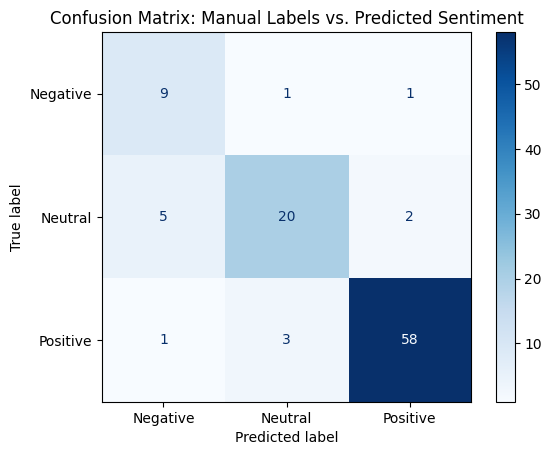

In [20]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Make a copy to avoid modifying the original DataFrame during manual labeling loop
manual_evaluation_df = sampled_comments_df.copy()

user_labels = []
print("Please classify each comment as P (Positive), N (Neutral), or Ng (Negative).")
print("Press 's' to skip to the next comment without labeling.")
print("Press 'q' to quit the labeling process early.")

for index, row in manual_evaluation_df.iterrows():
    comment = row['comment']
    predicted = row['predicted_sentiment']
    print(f"\n--- Comment {index + 1}/{len(manual_evaluation_df)} ---")
    print(f"Comment: {comment}")
    print(f"Predicted Sentiment: {predicted}")

    while True:
        user_input = input("Your classification (P/N/Ng/s/q): ").strip().lower()
        if user_input == 'p':
            user_labels.append('Positive')
            break
        elif user_input == 'n':
            user_labels.append('Neutral')
            break
        elif user_input == 'ng':
            user_labels.append('Negative')
            break
        elif user_input == 's':
            user_labels.append(np.nan) # Append NaN for skipped comments
            break
        elif user_input == 'q':
            print("Labeling process quit by user.")
            break
        else:
            print("Invalid input. Please enter P, N, Ng, s, or q.")
    if user_input == 'q':
        break

# Truncate manual_evaluation_df and predicted_sentiment to match the length of user_labels
manual_evaluation_df = manual_evaluation_df.iloc[:len(user_labels)]
manual_evaluation_df['true_label'] = user_labels

# Filter out rows where 'true_label' is NaN (skipped comments) for evaluation
evaluation_df = manual_evaluation_df.dropna(subset=['true_label'])

if not evaluation_df.empty:
    y_true = evaluation_df['true_label']
    y_pred = evaluation_df['predicted_sentiment']

    # Define all possible labels to ensure consistency in reports/plots
    all_labels = sorted(list(set(y_true) | set(y_pred)))

    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, labels=all_labels, zero_division=0))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_labels)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title('Confusion Matrix: Manual Labels vs. Predicted Sentiment')
    plt.show()
else:
    print("\nNo comments were labeled. Cannot generate classification report or confusion matrix.")
